In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Clima y comportamiento de compra

Se usan tickets cerrados como medida de compras. No se usa `Personas` porque ese dato no se captura de forma confiable.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE = '/content/drive/MyDrive/Portfolio/02_Restaurant_Sales/data'

Se toma la hora de `Creación` y no la de cierre. Algunos tickets se cierran juntos al final del turno por temas administrativos.

In [3]:
df = pd.read_excel(f'{BASE}/VENTAS_2025.xls', sheet_name='Ventas', skiprows=3)
df_26 = pd.read_excel(f'{BASE}/VENTAS_ANUAL_2026.xlsx', sheet_name='Ventas', skiprows=3)

df = pd.concat([df, df_26], ignore_index=True)

df['Creación'] = pd.to_datetime(df['Creación'])
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

df = df[(df['Estado'] == 'Cerrada') & (df['Total'] > 0)].copy()

df['Fecha'] = df['Creación'].dt.date
df['Año'] = df['Creación'].dt.year
df['Mes'] = df['Creación'].dt.month
df['Dia'] = df['Creación'].dt.day
df['Dia_semana'] = df['Creación'].dt.dayofweek
df['Hora'] = df['Creación'].dt.hour

df = df[(df['Hora'] >= 8) & (df['Hora'] <= 21)].copy()

print('Tickets válidos en horario de operación:', len(df))
print('Periodo de ventas:', df['Fecha'].min(), 'a', df['Fecha'].max())

Tickets válidos en horario de operación: 12519
Periodo de ventas: 2025-01-01 a 2026-10-06


In [4]:
df_clima = pd.read_csv(f'{BASE}/tiempo_01-01-2025--30-09-2026.csv', skiprows=3)

df_clima['time'] = pd.to_datetime(df_clima['time'])
df_clima['Fecha'] = df_clima['time'].dt.date
df_clima['Hora'] = df_clima['time'].dt.hour
df_clima['Año'] = df_clima['time'].dt.year
df_clima['Mes'] = df_clima['time'].dt.month

df_clima = df_clima.rename(columns={
    'temperature_2m (°C)': 'temp',
    'rain (mm)': 'lluvia',
    'apparent_temperature (°C)': 'temp_aparente',
    'relative_humidity_2m (%)': 'humedad',
})

df_clima = df_clima[(df_clima['Hora'] >= 8) & (df_clima['Hora'] <= 21)].copy()

ventas = df.groupby(['Fecha', 'Hora'], as_index=False).agg(
    tickets=('Id', 'count'),
    ingreso=('Total', 'sum')
)

merged = df_clima.merge(ventas, on=['Fecha', 'Hora'], how='left')

merged[['tickets', 'ingreso']] = merged[['tickets', 'ingreso']].fillna(0)
merged['tickets'] = merged['tickets'].astype(int)
merged['ticket_prom'] = merged['ingreso'].div(merged['tickets']).where(merged['tickets'] > 0)

print('Periodo con clima disponible:', merged['Fecha'].min(), 'a', merged['Fecha'].max())
print('Horas sin ventas:', (merged['tickets'] == 0).sum())

Periodo con clima disponible: 2025-01-01 a 2026-09-30
Horas sin ventas: 3074


## Correlación general

Esta matriz es exploratoria. Todavía mezcla horas del día, meses y los dos años.

In [5]:
corr = merged[[
    'tickets', 'ingreso', 'ticket_prom',
    'temp', 'temp_aparente', 'lluvia', 'humedad'
]].corr()

corr.round(2)

,tickets,ingreso,ticket_prom,temp,temp_aparente,lluvia,humedad
tickets,1.00,0.60,0.00,0.19,0.19,-0.03,-0.14
ingreso,0.60,1.00,0.68,0.12,0.12,-0.01,-0.08
ticket_prom,0.00,0.68,1.00,0.02,0.01,0.02,-0.00
temp,0.19,0.12,0.02,1.00,0.91,-0.18,-0.79
temp_aparente,0.19,0.12,0.01,0.91,1.00,-0.11,-0.54
lluvia,-0.03,-0.01,0.02,-0.18,-0.11,1.00,0.33
humedad,-0.14,-0.08,-0.00,-0.79,-0.54,0.33,1.00


## Correlación dentro de cada hora

Aquí se compara, por ejemplo, una tarde calurosa contra otras tardes, sin confundir el calor normal de las 2pm con que esa hora suele vender más.

In [6]:
filas = []

for hora, por_hora in merged.groupby('Hora'):
    por_hora = por_hora[['tickets', 'temp', 'temp_aparente', 'lluvia', 'humedad']].dropna()

    if len(por_hora) >= 30:
        c = por_hora.corr().loc['tickets']

        filas.append({
            'Hora': hora,
            'observaciones': len(por_hora),
            'temp': c['temp'],
            'temp_aparente': c['temp_aparente'],
            'lluvia': c['lluvia'],
            'humedad': c['humedad']
        })

corr_hora = pd.DataFrame(filas).sort_values('Hora')

corr_hora.round(2)

,Hora,observaciones,temp,temp_aparente,lluvia,humedad
0,8,638,0.09,0.13,0.05,0.07
1,9,638,0.09,0.10,-0.04,-0.02
2,10,638,0.04,0.06,0.01,0.00
3,11,638,-0.04,-0.04,-0.01,0.05
4,12,638,-0.10,-0.11,-0.03,0.07
5,13,638,0.03,0.05,-0.02,0.02
6,14,638,0.07,0.07,-0.02,-0.03
7,15,638,0.01,0.06,0.07,0.07
8,16,638,-0.01,0.01,-0.00,0.02
9,17,638,-0.04,0.02,0.02,0.08


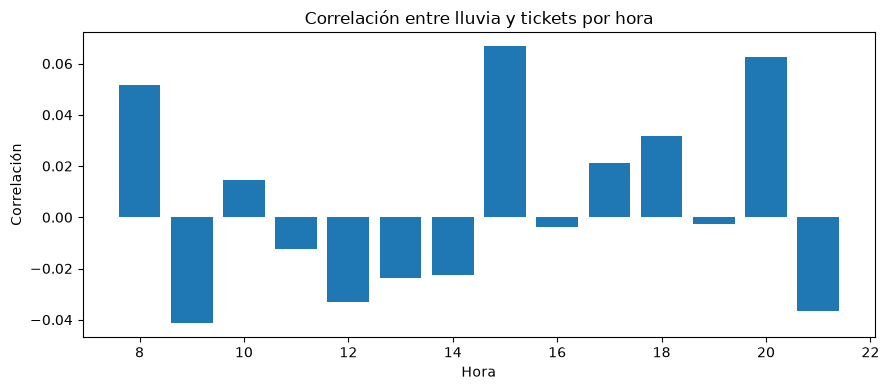

In [7]:
plt.figure(figsize=(9, 4))
plt.bar(corr_hora['Hora'], corr_hora['lluvia'])
plt.title('Correlación entre lluvia y tickets por hora')
plt.xlabel('Hora')
plt.ylabel('Correlación')
plt.tight_layout()
plt.show()

## Ticket promedio con lluvia

Para esta comparación se excluyen las horas sin ventas porque no tienen ticket promedio. El promedio se calcula dentro de la misma combinación de año, mes y hora.

In [8]:
con_ticket = merged[merged['tickets'] > 0].copy()
con_ticket = con_ticket.dropna(subset=['lluvia', 'temp'])

con_ticket['llueve'] = con_ticket['lluvia'] > 0

por_lluvia = con_ticket.groupby(
    ['Año', 'Mes', 'Hora', 'llueve'],
    as_index=False
).agg(
    tickets=('tickets', 'sum'),
    ingreso=('ingreso', 'sum')
)

por_lluvia['ticket_prom'] = por_lluvia['ingreso'] / por_lluvia['tickets']

piv_lluvia = por_lluvia.pivot(
    index=['Año', 'Mes', 'Hora'],
    columns='llueve',
    values='ticket_prom'
)

piv_lluvia = piv_lluvia.reindex(columns=[False, True])
piv_lluvia.columns = ['sin_lluvia', 'con_lluvia']

comp_lluvia = piv_lluvia.dropna()

res_lluvia = comp_lluvia.groupby(level='Año')[['sin_lluvia', 'con_lluvia']].mean()
res_lluvia['franjas_comparables'] = comp_lluvia.groupby(level='Año').size()

total_lluvia = pd.DataFrame({
    'sin_lluvia': [comp_lluvia['sin_lluvia'].mean()],
    'con_lluvia': [comp_lluvia['con_lluvia'].mean()],
    'franjas_comparables': [len(comp_lluvia)]
}, index=['Total controlado'])

res_lluvia = pd.concat([res_lluvia, total_lluvia])

res_lluvia['dif_pesos'] = res_lluvia['con_lluvia'] - res_lluvia['sin_lluvia']
res_lluvia['cambio_%'] = res_lluvia['dif_pesos'] / res_lluvia['sin_lluvia'] * 100
res_lluvia['lectura'] = 'diferencia pequeña (<10%)'
res_lluvia.loc[res_lluvia['cambio_%'].abs() >= 10, 'lectura'] = 'diferencia relevante (>=10%)'

res_lluvia.round(2)

,sin_lluvia,con_lluvia,franjas_comparables,dif_pesos,cambio_%,lectura
2025,258.78,254.02,93,-4.75,-1.84,diferencia pequeña (<10%)
2026,316.80,246.69,77,-70.11,-22.13,diferencia relevante (>=10%)
Total controlado,285.06,250.70,170,-34.35,-12.05,diferencia relevante (>=10%)


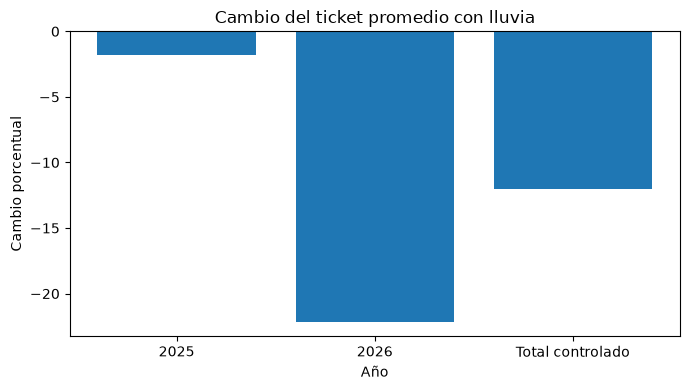

In [9]:
plt.figure(figsize=(7, 4))
plt.bar(res_lluvia.index.astype(str), res_lluvia['cambio_%'])
plt.title('Cambio del ticket promedio con lluvia')
plt.xlabel('Año')
plt.ylabel('Cambio porcentual')
plt.tight_layout()
plt.show()

## Ticket promedio con calor fuerte

Se considera calor fuerte una temperatura arriba del percentil 90 de las horas de operación disponibles.

In [10]:
umbral_calor = merged['temp'].quantile(0.90)

con_ticket['calor'] = con_ticket['temp'] > umbral_calor

por_calor = con_ticket.groupby(
    ['Año', 'Mes', 'Hora', 'calor'],
    as_index=False
).agg(
    tickets=('tickets', 'sum'),
    ingreso=('ingreso', 'sum')
)

por_calor['ticket_prom'] = por_calor['ingreso'] / por_calor['tickets']

piv_calor = por_calor.pivot(
    index=['Año', 'Mes', 'Hora'],
    columns='calor',
    values='ticket_prom'
)

piv_calor = piv_calor.reindex(columns=[False, True])
piv_calor.columns = ['resto', 'calor_fuerte']

comp_calor = piv_calor.dropna()

res_calor = comp_calor.groupby(level='Año')[['resto', 'calor_fuerte']].mean()
res_calor['franjas_comparables'] = comp_calor.groupby(level='Año').size()

total_calor = pd.DataFrame({
    'resto': [comp_calor['resto'].mean()],
    'calor_fuerte': [comp_calor['calor_fuerte'].mean()],
    'franjas_comparables': [len(comp_calor)]
}, index=['Total controlado'])

res_calor = pd.concat([res_calor, total_calor])

res_calor['dif_pesos'] = res_calor['calor_fuerte'] - res_calor['resto']
res_calor['cambio_%'] = res_calor['dif_pesos'] / res_calor['resto'] * 100
res_calor['lectura'] = 'diferencia pequeña (<10%)'
res_calor.loc[res_calor['cambio_%'].abs() >= 10, 'lectura'] = 'diferencia relevante (>=10%)'

print(f'Percentil 90 de temperatura: {umbral_calor:.1f} °C')
res_calor.round(2)

Percentil 90 de temperatura: 34.6 °C


,resto,calor_fuerte,franjas_comparables,dif_pesos,cambio_%,lectura
2025,234.41,237.02,36,2.62,1.12,diferencia pequeña (<10%)
2026,304.79,270.87,45,-33.91,-11.13,diferencia relevante (>=10%)
Total controlado,273.51,255.83,81,-17.68,-6.46,diferencia pequeña (<10%)


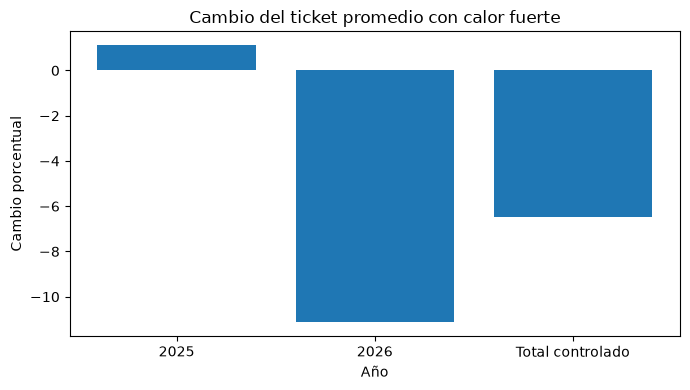

In [11]:
plt.figure(figsize=(7, 4))
plt.bar(res_calor.index.astype(str), res_calor['cambio_%'])
plt.title('Cambio del ticket promedio con calor fuerte')
plt.xlabel('Año')
plt.ylabel('Cambio porcentual')
plt.tight_layout()
plt.show()

## Control por cambios del negocio

No se comparan directamente los tickets de 2025 contra los de 2026 para atribuir cambios al clima. Desde diciembre de 2025 dejó de estar el mercado cercano y en enero de 2026 el restaurante se mudó y ajustó precios.

Por eso las pruebas anteriores comparan horas con y sin lluvia, o con y sin calor fuerte, dentro del mismo año, mes y hora. Así se reduce el efecto de la mudanza, la pérdida del mercado, los precios y la estacionalidad mensual.

In [12]:
lluvia_total = res_lluvia.loc['Total controlado', 'con_lluvia']
lluvia_cambio = res_lluvia.loc['Total controlado', 'cambio_%']

calor_total = res_calor.loc['Total controlado', 'calor_fuerte']
calor_cambio = res_calor.loc['Total controlado', 'cambio_%']

bajo_lluvia = (lluvia_total <= 120) and (lluvia_cambio <= -10)
bajo_calor = (calor_total <= 120) and (calor_cambio <= -10)

if bajo_lluvia and bajo_calor:
    cierre = 'La hipótesis del dueño es compatible con lo que se ve para lluvia y para calor fuerte: en ambos casos aparece un ticket bajo y una baja relevante frente a horas comparables.'
elif bajo_lluvia:
    cierre = 'La hipótesis es compatible solo en parte: la señal aparece con lluvia, pero no se repite con calor fuerte.'
elif bajo_calor:
    cierre = 'La hipótesis es compatible solo en parte: la señal aparece con calor fuerte, pero no se repite con lluvia.'
else:
    cierre = 'La hipótesis no encuentra respaldo claro: no aparece un ticket bajo junto con una baja relevante en horas comparables de lluvia o calor fuerte.'

display(Markdown(
    f"""
## Resultado

{cierre}

- Ticket controlado con lluvia: **${lluvia_total:,.0f}**, cambio de **{lluvia_cambio:.1f}%** frente a horas sin lluvia.
- Ticket controlado con calor fuerte: **${calor_total:,.0f}**, cambio de **{calor_cambio:.1f}%** frente al resto de horas.
- Calor fuerte se definió como una temperatura mayor a **{umbral_calor:.1f} °C**.

Una correlación o una diferencia pequeña no prueba que la gente entre solo a resguardarse. Para sostener esa idea tendría que verse un ticket realmente bajo y una caída consistente después de controlar la hora, el mes y el año.
"""
))


## Resultado

La hipótesis no encuentra respaldo claro: no aparece un ticket bajo junto con una baja relevante en horas comparables de lluvia o calor fuerte.

- Ticket controlado con lluvia: **$251**, cambio de **-12.1%** frente a horas sin lluvia.
- Ticket controlado con calor fuerte: **$256**, cambio de **-6.5%** frente al resto de horas.
- Calor fuerte se definió como una temperatura mayor a **34.6 °C**.

Una correlación o una diferencia pequeña no prueba que la gente entre solo a resguardarse. Para sostener esa idea tendría que verse un ticket realmente bajo y una caída consistente después de controlar la hora, el mes y el año.


## Cierre

La conclusión calculada arriba prioriza la comparación dentro de la misma franja horaria, mes y año. Esto reduce la posibilidad de confundir el clima con cambios estructurales del negocio, como la pérdida del mercado, la mudanza al parque y el aumento de precios de 2026.